In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_PATH = PROJECT_ROOT / "Data" / "processed"

# Load cleaned Bank Marketing data
bank_marketing = pd.read_csv(
    PROCESSED_PATH / "bank_marketing_clean.csv"
)

print("Dataset shape:", bank_marketing.shape)

display(bank_marketing.head())

print("\nColumns:")
print(bank_marketing.columns.tolist())

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [2]:
print("Missing values:")
display(
    bank_marketing.isnull().sum()
    .sort_values(ascending=False)
)

print("\nData types:")
display(bank_marketing.dtypes)

print("\nTarget distribution:")
display(
    bank_marketing["y"]
    .value_counts()
    .to_frame("customers")
)

print("\nTarget percentage:")
display(
    (
        bank_marketing["y"]
        .value_counts(normalize=True) * 100
    )
    .round(2)
    .to_frame("percentage")
)

Missing values:


age          0
day          0
poutcome     0
previous     0
pdays        0
campaign     0
duration     0
month        0
contact      0
job          0
loan         0
housing      0
balance      0
default      0
education    0
marital      0
y            0
dtype: int64


Data types:


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


Target distribution:


,customers
y,
no,39922
yes,5289



Target percentage:


,percentage
y,
no,88.3
yes,11.7


In [3]:
# ==========================================
# CUSTOMER PROFILE CONVERSION ANALYSIS
# ==========================================

profile_columns = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "contact"
]

for column in profile_columns:

    summary = (
        bank_marketing
        .groupby(column)["y"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
        .to_frame("conversion_rate_percent")
    )

    print(f"\n{'=' * 60}")
    print(f"{column.upper()} — SUBSCRIPTION RATE")
    print(f"{'=' * 60}")

    display(summary)


JOB — SUBSCRIPTION RATE


,conversion_rate_percent
job,
student,28.68
retired,22.79
unemployed,15.50
management,13.76
admin.,12.20
self-employed,11.84
unknown,11.81
technician,11.06
services,8.88



MARITAL — SUBSCRIPTION RATE


,conversion_rate_percent
marital,
single,14.95
divorced,11.95
married,10.12



EDUCATION — SUBSCRIPTION RATE


...

,conversion_rate_percent
housing,
no,16.7
yes,7.7



LOAN — SUBSCRIPTION RATE


,conversion_rate_percent
loan,
no,12.66
yes,6.68



CONTACT — SUBSCRIPTION RATE


,conversion_rate_percent
contact,
cellular,14.92
telephone,13.42
unknown,4.07


In [4]:
# ==========================================
# CAMPAIGN PERFORMANCE ANALYSIS
# ==========================================

campaign_summary = (
    bank_marketing
    .groupby("campaign")
    .agg(
        customers=("y", "count"),
        subscriptions=("y", lambda x: (x == "yes").sum())
    )
    .reset_index()
)

campaign_summary["conversion_rate_percent"] = (
    campaign_summary["subscriptions"]
    / campaign_summary["customers"]
    * 100
).round(2)

campaign_summary = campaign_summary[
    campaign_summary["customers"] >= 50
].sort_values(
    "conversion_rate_percent",
    ascending=False
)

display(campaign_summary.head(15))

,campaign,customers,subscriptions,conversion_rate_percent
0,1,17544,2561,14.60
1,2,12505,1401,11.20
2,3,5521,618,11.19
3,4,3522,317,9.00
16,17,69,6,8.70
10,11,201,16,7.96
4,5,1764,139,7.88
5,6,1291,92,7.13
8,9,327,21,6.42
6,7,735,47,6.39


In [5]:
# ==========================================
# PREVIOUS CAMPAIGN OUTCOME
# ==========================================

previous_outcome = (
    bank_marketing
    .groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
    .to_frame("conversion_rate_percent")
)

display(previous_outcome)

,conversion_rate_percent
poutcome,
success,64.73
other,16.68
failure,12.61
unknown,9.16


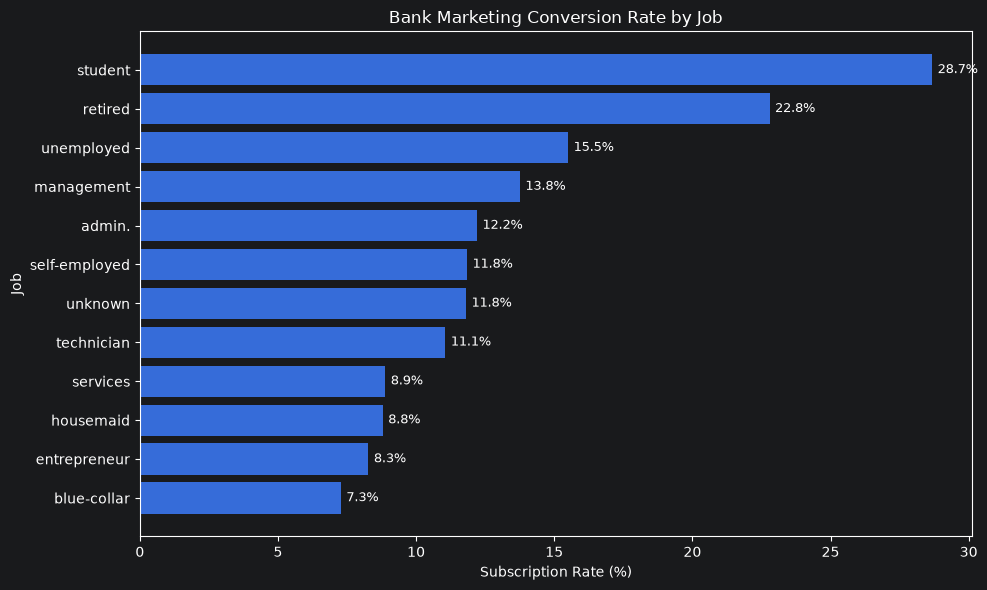

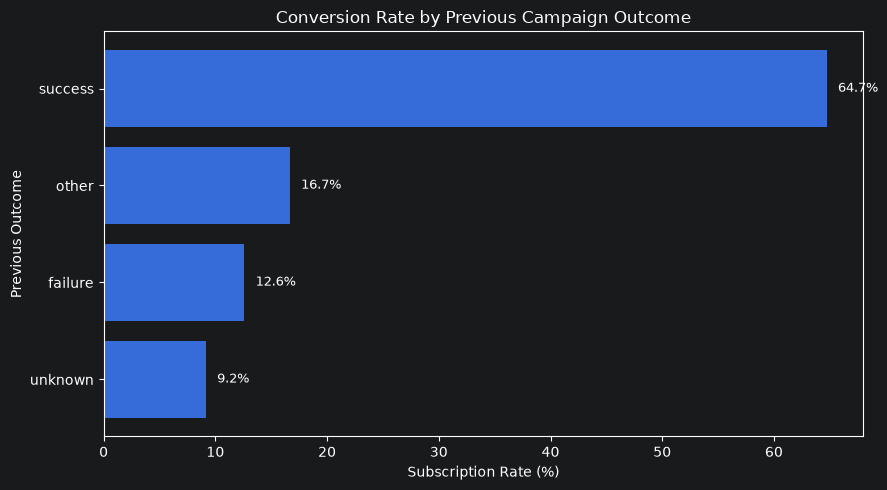

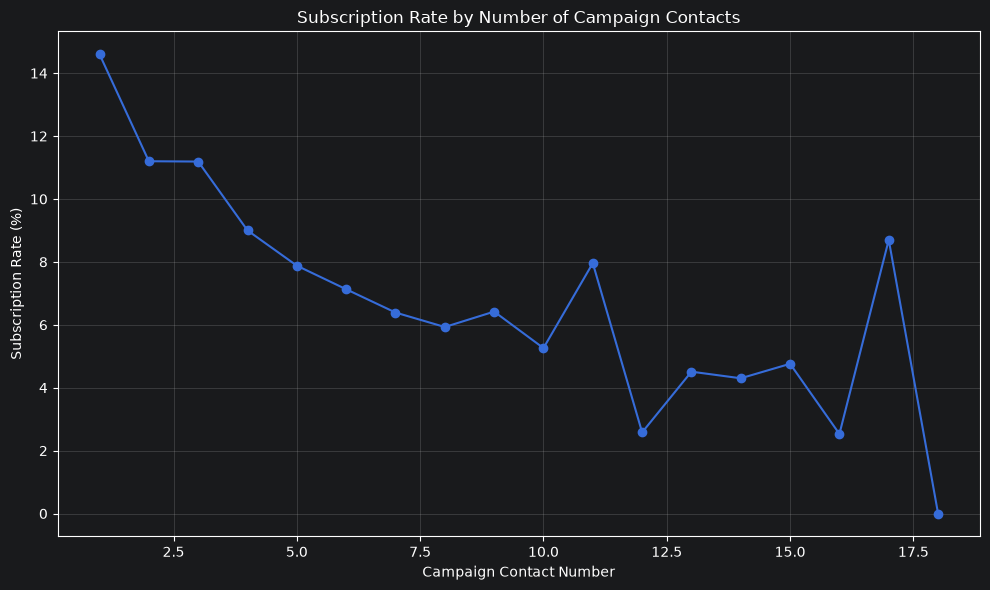

In [6]:
# ==========================================
# BANK MARKETING VISUALIZATIONS
# ==========================================

import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Conversion Rate by Job
# ------------------------------------------

job_conversion = (
    bank_marketing
    .groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    job_conversion.index,
    job_conversion.values
)

plt.title("Bank Marketing Conversion Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

for i, value in enumerate(job_conversion.values):
    plt.text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "marketing_conversion_by_job.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 2. Conversion Rate by Previous Outcome
# ------------------------------------------

previous_plot = previous_outcome.sort_values(
    "conversion_rate_percent",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    previous_plot.index,
    previous_plot["conversion_rate_percent"]
)

plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Previous Outcome")

for i, value in enumerate(
    previous_plot["conversion_rate_percent"]
):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "marketing_conversion_by_previous_outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 3. Conversion Rate by Campaign Contacts
# ------------------------------------------

campaign_plot = campaign_summary.sort_values(
    "campaign"
)

plt.figure(figsize=(10, 6))

plt.plot(
    campaign_plot["campaign"],
    campaign_plot["conversion_rate_percent"],
    marker="o"
)

plt.title("Subscription Rate by Number of Campaign Contacts")
plt.xlabel("Campaign Contact Number")
plt.ylabel("Subscription Rate (%)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "marketing_campaign_conversion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# ==========================================
# CONTACT DURATION ANALYSIS
# ==========================================

duration_summary = (
    bank_marketing
    .groupby("y")["duration"]
    .agg(
        customers="count",
        average_duration_seconds="mean",
        median_duration_seconds="median"
    )
    .round(2)
)

display(duration_summary)

,customers,average_duration_seconds,median_duration_seconds
y,,,
no,39922,221.18,164.0
yes,5289,537.29,426.0


In [8]:
# ==========================================
# CONTACT DURATION BANDS
# ==========================================

bank_marketing["duration_band"] = pd.cut(
    bank_marketing["duration"],
    bins=[-1, 60, 180, 300, 600, np.inf],
    labels=[
        "0-1 min",
        "1-3 min",
        "3-5 min",
        "5-10 min",
        "10+ min"
    ]
)

duration_conversion = (
    bank_marketing
    .groupby("duration_band", observed=False)["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .round(2)
    .to_frame("conversion_rate_percent")
)

display(duration_conversion)

,conversion_rate_percent
duration_band,
0-1 min,0.19
1-3 min,3.91
3-5 min,10.92
5-10 min,19.15
10+ min,48.36


In [9]:
# ==========================================
# MARKETING KPI SUMMARY
# ==========================================

total_customers = len(bank_marketing)

total_subscriptions = (
    bank_marketing["y"] == "yes"
).sum()

overall_conversion_rate = (
    total_subscriptions / total_customers * 100
)

avg_age = bank_marketing["age"].mean()

avg_balance = bank_marketing["balance"].mean()

avg_campaign_contacts = bank_marketing["campaign"].mean()

avg_call_duration = bank_marketing["duration"].mean()

successful_previous = (
    bank_marketing["poutcome"] == "success"
).sum()

marketing_kpis = pd.DataFrame({
    "Metric": [
        "Total Customers Contacted",
        "Total Subscriptions",
        "Overall Conversion Rate (%)",
        "Average Customer Age",
        "Average Account Balance",
        "Average Campaign Contacts",
        "Average Call Duration (Seconds)",
        "Customers with Previous Campaign Success"
    ],
    "Value": [
        total_customers,
        total_subscriptions,
        round(overall_conversion_rate, 2),
        round(avg_age, 2),
        round(avg_balance, 2),
        round(avg_campaign_contacts, 2),
        round(avg_call_duration, 2),
        successful_previous
    ]
})

display(marketing_kpis)

,Metric,Value
0,Total Customers Contacted,45211.00
1,Total Subscriptions,5289.00
2,Overall Conversion Rate (%),11.70
3,Average Customer Age,40.94
4,Average Account Balance,1362.27
5,Average Campaign Contacts,2.76
6,Average Call Duration (Seconds),258.16
7,Customers with Previous Campaign Success,1511.00


In [10]:
# ==========================================
# SAVE MARKETING ANALYTICS OUTPUTS
# ==========================================

marketing_kpis.to_csv(
    PROCESSED_PATH / "marketing_kpis.csv",
    index=False
)

job_conversion.to_frame(
    "conversion_rate_percent"
).to_csv(
    PROCESSED_PATH / "marketing_job_conversion.csv"
)

previous_outcome.to_csv(
    PROCESSED_PATH / "marketing_previous_outcome.csv"
)

campaign_summary.to_csv(
    PROCESSED_PATH / "marketing_campaign_performance.csv",
    index=False
)

duration_conversion.to_csv(
    PROCESSED_PATH / "marketing_duration_conversion.csv"
)

print("Marketing analytics outputs saved successfully.")

Marketing analytics outputs saved successfully.


In [11]:
# ==========================================
# KEY MARKETING INSIGHTS
# ==========================================

top_job = job_conversion.idxmax()
top_job_rate = job_conversion.max()

best_previous_outcome = previous_outcome[
    "conversion_rate_percent"
].idxmax()

best_previous_rate = previous_outcome[
    "conversion_rate_percent"
].max()

best_campaign = campaign_summary.iloc[0]["campaign"]
best_campaign_rate = campaign_summary.iloc[0]["conversion_rate_percent"]

best_duration_band = duration_conversion[
    "conversion_rate_percent"
].idxmax()

best_duration_rate = duration_conversion[
    "conversion_rate_percent"
].max()

marketing_insights = pd.DataFrame({
    "Insight": [
        "Highest-converting job category",
        "Strongest previous campaign outcome",
        "Highest-converting campaign number",
        "Highest-converting duration band",
        "Overall campaign conversion rate"
    ],
    "Result": [
        f"{top_job} ({top_job_rate:.2f}%)",
        f"{best_previous_outcome} ({best_previous_rate:.2f}%)",
        f"Campaign {int(best_campaign)} ({best_campaign_rate:.2f}%)",
        f"{best_duration_band} ({best_duration_rate:.2f}%)",
        f"{overall_conversion_rate:.2f}%"
    ]
})

display(marketing_insights)

,Insight,Result
0,Highest-converting job category,student (28.68%)
1,Strongest previous campaign outcome,success (64.73%)
2,Highest-converting campaign number,Campaign 1 (14.60%)
3,Highest-converting duration band,10+ min (48.36%)
4,Overall campaign conversion rate,11.70%


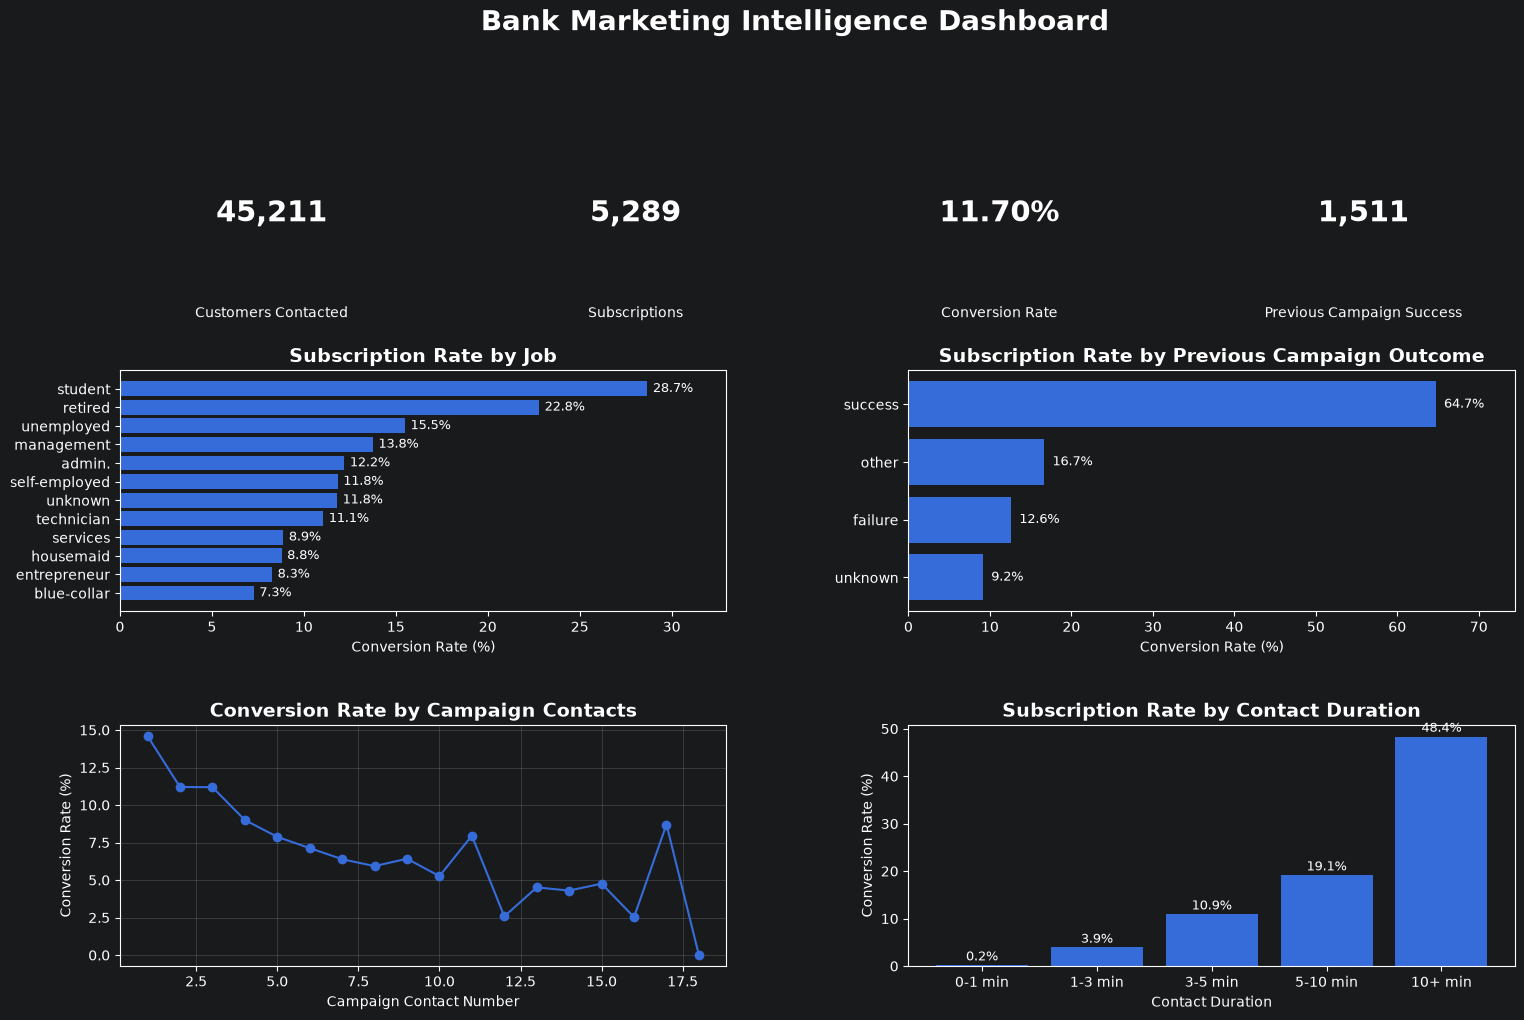

In [12]:
# ==========================================
# MARKETING INTELLIGENCE DASHBOARD
# ==========================================

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(figsize=(18, 11))

gs = fig.add_gridspec(
    3, 2,
    height_ratios=[0.8, 1.4, 1.4],
    hspace=0.55,
    wspace=0.30
)

# ==========================================
# KPI SECTION
# ==========================================

kpis = [
    ("Customers Contacted", f"{total_customers:,}"),
    ("Subscriptions", f"{total_subscriptions:,}"),
    ("Conversion Rate", f"{overall_conversion_rate:.2f}%"),
    ("Previous Campaign Success", f"{successful_previous:,}")
]

for i, (label, value) in enumerate(kpis):

    ax = fig.add_subplot(3, 4, i + 1)

    ax.text(
        0.5, 0.62,
        value,
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.22,
        label,
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ==========================================
# 1. CONVERSION BY JOB
# ==========================================

ax1 = fig.add_subplot(gs[1, 0])

job_plot = job_conversion.sort_values(ascending=True)

ax1.barh(
    job_plot.index,
    job_plot.values
)

ax1.set_title(
    "Subscription Rate by Job",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Conversion Rate (%)")

for i, value in enumerate(job_plot.values):

    ax1.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

ax1.set_xlim(
    0,
    job_plot.max() * 1.15
)


# ==========================================
# 2. PREVIOUS CAMPAIGN OUTCOME
# ==========================================

ax2 = fig.add_subplot(gs[1, 1])

previous_plot = previous_outcome.sort_values(
    "conversion_rate_percent",
    ascending=True
)

ax2.barh(
    previous_plot.index,
    previous_plot["conversion_rate_percent"]
)

ax2.set_title(
    "Subscription Rate by Previous Campaign Outcome",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Conversion Rate (%)")

for i, value in enumerate(
    previous_plot["conversion_rate_percent"]
):

    ax2.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

ax2.set_xlim(
    0,
    previous_plot["conversion_rate_percent"].max() * 1.15
)


# ==========================================
# 3. CAMPAIGN CONTACT EFFECT
# ==========================================

ax3 = fig.add_subplot(gs[2, 0])

campaign_plot = campaign_summary.sort_values(
    "campaign"
)

ax3.plot(
    campaign_plot["campaign"],
    campaign_plot["conversion_rate_percent"],
    marker="o"
)

ax3.set_title(
    "Conversion Rate by Campaign Contacts",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Campaign Contact Number")
ax3.set_ylabel("Conversion Rate (%)")

ax3.grid(True, alpha=0.3)


# ==========================================
# 4. CONTACT DURATION
# ==========================================

ax4 = fig.add_subplot(gs[2, 1])

duration_plot = duration_conversion.copy()

ax4.bar(
    duration_plot.index.astype(str),
    duration_plot["conversion_rate_percent"]
)

ax4.set_title(
    "Subscription Rate by Contact Duration",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Contact Duration")
ax4.set_ylabel("Conversion Rate (%)")

for i, value in enumerate(
    duration_plot["conversion_rate_percent"]
):

    ax4.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )


# ==========================================
# TITLE
# ==========================================

fig.suptitle(
    "Bank Marketing Intelligence Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)


# ==========================================
# SAVE
# ==========================================

plt.savefig(
    "bank_marketing_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ==========================================
# VERIFY ALL MARKETING OUTPUT FILES
# ==========================================

marketing_files = [
    "marketing_kpis.csv",
    "marketing_job_conversion.csv",
    "marketing_previous_outcome.csv",
    "marketing_campaign_performance.csv",
    "marketing_duration_conversion.csv"
]

for file_name in marketing_files:

    file_path = PROCESSED_PATH / file_name

    if file_path.exists():
        print(f"✓ {file_name}")
    else:
        print(f"✗ MISSING: {file_name}")

✓ marketing_kpis.csv
✓ marketing_job_conversion.csv
✓ marketing_previous_outcome.csv
✓ marketing_campaign_performance.csv
✓ marketing_duration_conversion.csv


In [14]:
# Verify dashboard image

dashboard_path = Path.cwd() / "bank_marketing_dashboard.png"

if dashboard_path.exists():
    print("✓ bank_marketing_dashboard.png")
else:
    print("✗ Dashboard image missing")

✓ bank_marketing_dashboard.png
